# Fake Face Detection

## 1) Import Libraries

In [14]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

## 2) Define Dataset Paths & Image Size

In [2]:
DATASET_PATH = "/kaggle/input/real-and-fake-face-detection/real_and_fake_face"

REAL_PATH = os.path.join(DATASET_PATH, "training_real")
FAKE_PATH = os.path.join(DATASET_PATH, "training_fake")

IMG_SIZE = 224

## 3) Load & Label Images

In [3]:
def load_images_from_folder(folder, label):
    images = []
    labels = []

    for filename in os.listdir(folder):
        img_path = os.path.join(folder, filename)

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images.append(img)
            labels.append(label)
        except:
            pass

    return images, labels


real_images, real_labels = load_images_from_folder(REAL_PATH, 0)
fake_images, fake_labels = load_images_from_folder(FAKE_PATH, 1)

X = np.array(real_images + fake_images)
y = np.array(real_labels + fake_labels)

print("Total images:", len(X))
print("Real images:", len(real_images))
print("Fake images:", len(fake_images))

Total images: 2041
Real images: 1081
Fake images: 960


## 4) Normalize & Split Data

In [4]:
X = X / 255.0 

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)

Training samples: (1632, 224, 224, 3)
Validation samples: (409, 224, 224, 3)


## 5) Quick Visual Check

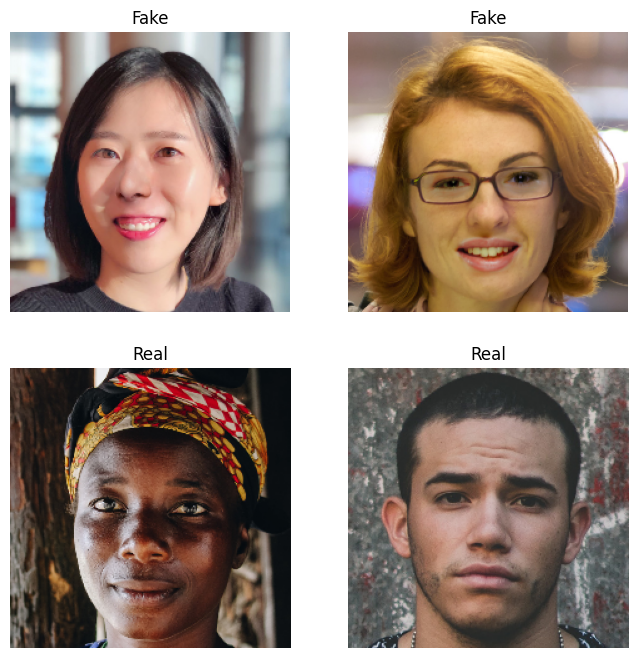

In [6]:
plt.figure(figsize=(8,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(X_train[i])
    plt.title("Fake" if y_train[i] == 1 else "Real")
    plt.axis("off")

plt.show()


## 6) Basic CNN

### i. Build the Basic CNN Architecture

In [11]:
basic_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

basic_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

### ii. Compile the Model

In [12]:
basic_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### iii. Train the Basic CNN

In [13]:
history_basic = basic_cnn.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.4875 - loss: 0.8415 - val_accuracy: 0.5306 - val_loss: 0.6926
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5326 - loss: 0.6933 - val_accuracy: 0.5306 - val_loss: 0.6915
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5197 - loss: 0.6945 - val_accuracy: 0.5306 - val_loss: 0.6897
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5143 - loss: 0.6904 - val_accuracy: 0.5697 - val_loss: 0.6846
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5520 - loss: 0.6786 - val_accuracy: 0.5917 - val_loss: 0.6690
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6242 - loss: 0.6462 - val_accuracy: 0.5868 - val_loss: 0.6728
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6378 - loss: 0.6343 - val_accuracy: 0.5868 - val_loss: 0.6691
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6863 - loss: 0.5804 - val_accuracy: 0.5697 - v

### iv. Evaluate the Model

In [14]:
y_pred = (basic_cnn.predict(X_val) > 0.5).astype(int)

print(classification_report(y_val, y_pred))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
              precision    recall  f1-score   support

           0       0.63      0.59      0.61       217
           1       0.57      0.61      0.59       192

    accuracy                           0.60       409
   macro avg       0.60      0.60      0.60       409
weighted avg       0.60      0.60      0.60       409



### v. Save the Model


In [20]:
os.makedirs("trained_models", exist_ok=True)
basic_cnn.save("trained_models/basic_cnn_fake_face.h5")

### vi. Plot Training Curves

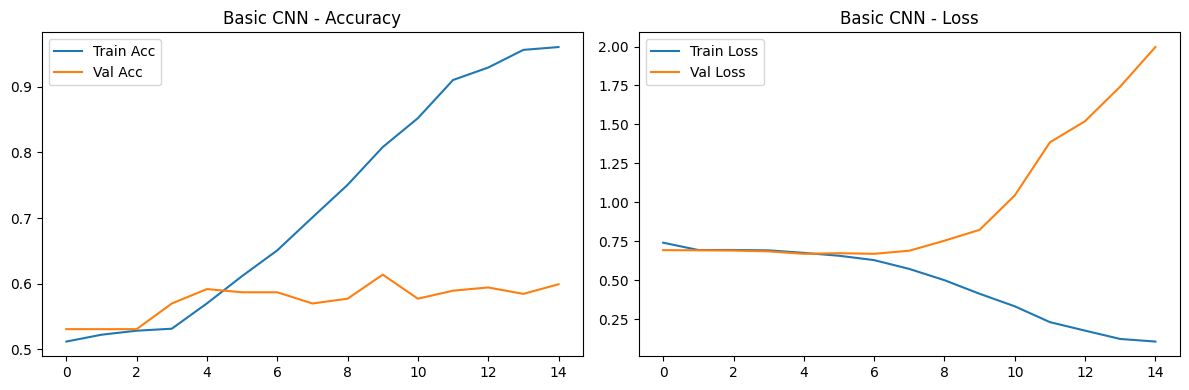

In [17]:
os.makedirs("plots", exist_ok=True)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_basic.history['accuracy'], label='Train Acc')
plt.plot(history_basic.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Basic CNN - Accuracy")

plt.subplot(1,2,2)
plt.plot(history_basic.history['loss'], label='Train Loss')
plt.plot(history_basic.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Basic CNN - Loss")

plt.tight_layout()
plt.savefig("plots/basic_cnn_training_curves.png")
plt.show()

### vii. Create and Save Confusion Matrix Plot

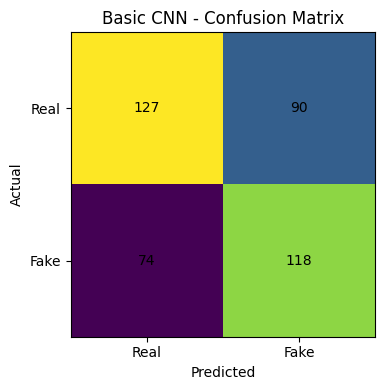

In [19]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Basic CNN - Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Real','Fake'])
plt.yticks([0,1], ['Real','Fake'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("plots/basic_cnn_confusion_matrix.png")
plt.show()


## 7) MobileNetV2

### i. Load Pretrained Base Model

In [26]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True  

### ii. Build the Full Model

In [27]:
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

mobilenet_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 2,387,969 (9.11 MB)

 Non-trainable params: 34,112 (133.25 KB)

### iii. Compile the Model

In [28]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### iv. Train MobileNetV2

In [29]:
history_mobilenet = mobilenet_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Epoch 1/10


E0000 00:00:1767775153.407789     149 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1767775153.605787     149 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


51/51 ━━━━━━━━━━━━━━━━━━━━ 50s 181ms/step - accuracy: 0.5438 - loss: 0.7713 - val_accuracy: 0.5306 - val_loss: 0.7388
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.7626 - loss: 0.4974 - val_accuracy: 0.5623 - val_loss: 0.7033
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.8632 - loss: 0.3452 - val_accuracy: 0.5819 - val_loss: 0.7197
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 87ms/step - accuracy: 0.9480 - loss: 0.1749 - val_accuracy: 0.6626 - val_loss: 0.6855
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9705 - loss: 0.0951 - val_accuracy: 0.6748 - val_loss: 0.7378
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9868 - loss: 0.0642 - val_accuracy: 0.6748 - val_loss: 0.7854
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9887 - loss: 0.0407 - val_accuracy: 0.6357 - val_loss: 1.0539
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.9902 - loss: 0.0353 - val_accuracy: 0.6773 - val_loss: 

### v. Evaluate MobileNetV2

In [30]:
y_pred_mn = (mobilenet_model.predict(X_val) > 0.5).astype(int)

print(classification_report(y_val, y_pred_mn))

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step
              precision    recall  f1-score   support

           0       0.72      0.56      0.63       217
           1       0.60      0.76      0.67       192

    accuracy                           0.65       409
   macro avg       0.66      0.66      0.65       409
weighted avg       0.67      0.65      0.65       409



### vi. Save the Model

In [31]:
mobilenet_model.save("trained_models/mobilenetv2_fake_face.h5")

### vii. Plot and Save Training Curves

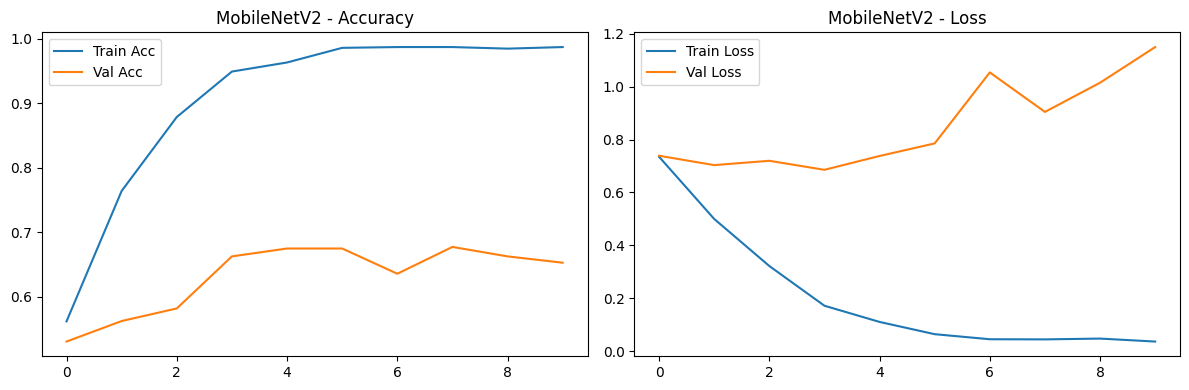

In [32]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_mobilenet.history['accuracy'], label='Train Acc')
plt.plot(history_mobilenet.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("MobileNetV2 - Accuracy")

plt.subplot(1,2,2)
plt.plot(history_mobilenet.history['loss'], label='Train Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("MobileNetV2 - Loss")

plt.tight_layout()
plt.savefig("plots/mobilenetv2_training_curves.png")
plt.show()

### viii. Confusion Matrix

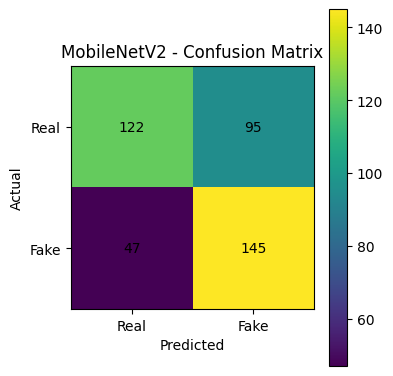

In [33]:
cm = confusion_matrix(y_val, y_pred_mn)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("MobileNetV2 - Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Real','Fake'])
plt.yticks([0,1], ['Real','Fake'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("plots/mobilenetv2_confusion_matrix.png")
plt.show()

## 8) Augmentation + CNN

### i. Create Data Generators

In [15]:
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
# no Augmentation for validation Data Generator
val_datagen = ImageDataGenerator()

### ii. Flow Data from Arrays

In [16]:
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=32
)

val_generator = val_datagen.flow(
    X_val, y_val,
    batch_size=32
)

### iii. Rebuild the SAME Basic CNN

In [17]:
aug_cnn = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### iv. Compile the Model

In [18]:
aug_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### v. Train with Augmentation

In [19]:
history_aug_cnn = aug_cnn.fit(
    train_generator,
    epochs=20,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 306ms/step - accuracy: 0.4716 - loss: 0.9043 - val_accuracy: 0.5306 - val_loss: 0.6928
Epoch 2/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 296ms/step - accuracy: 0.5392 - loss: 0.6927 - val_accuracy: 0.5208 - val_loss: 0.6918
Epoch 3/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 290ms/step - accuracy: 0.5220 - loss: 0.6922 - val_accuracy: 0.5257 - val_loss: 0.6879
Epoch 4/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 306ms/step - accuracy: 0.5407 - loss: 0.6917 - val_accuracy: 0.5306 - val_loss: 0.6917
Epoch 5/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 306ms/step - accuracy: 0.5288 - loss: 0.6920 - val_accuracy: 0.5306 - val_loss: 0.6914
Epoch 6/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 303ms/step - accuracy: 0.5443 - loss: 0.6921 - val_accuracy: 0.5306 - val_loss: 0.6913
Epoch 7/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 299ms/step - accuracy: 0.5128 - loss: 0.6929 - val_accuracy: 0.5306 - val_loss: 0.6913
Epoch 8/20
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 289ms/step - accuracy: 0.5239 - loss: 0.6925 - val_accu

### vi. Evaluate Model

In [20]:
y_pred_aug = (aug_cnn.predict(X_val) > 0.5).astype(int)

print(classification_report(y_val, y_pred_aug))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
              precision    recall  f1-score   support

           0       0.53      1.00      0.69       217
           1       0.00      0.00      0.00       192

    accuracy                           0.53       409
   macro avg       0.27      0.50      0.35       409
weighted avg       0.28      0.53      0.37       409



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### vii. Save the Model

In [21]:
aug_cnn.save("trained_models/augmented_cnn_fake_face.h5")

### viii. Plot and Save Training Curves

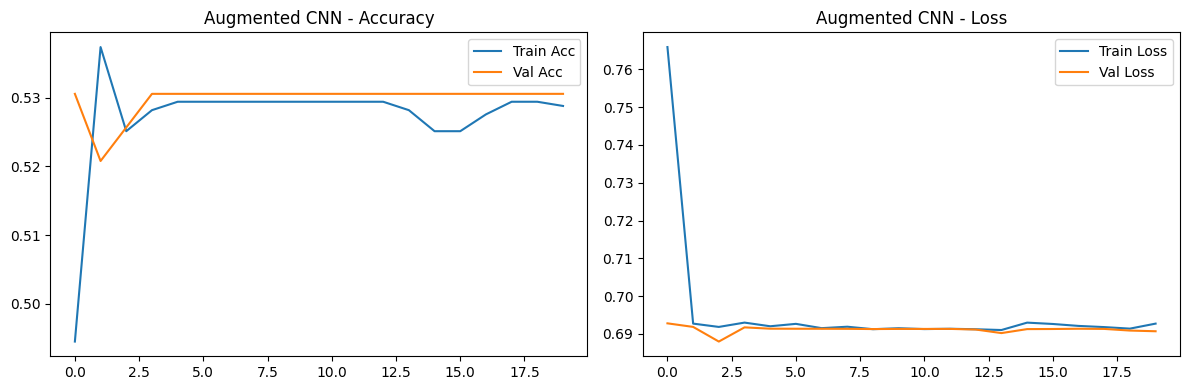

In [22]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_aug_cnn.history['accuracy'], label='Train Acc')
plt.plot(history_aug_cnn.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Augmented CNN - Accuracy")

plt.subplot(1,2,2)
plt.plot(history_aug_cnn.history['loss'], label='Train Loss')
plt.plot(history_aug_cnn.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Augmented CNN - Loss")

plt.tight_layout()
plt.savefig("plots/aug_cnn_training_curves.png")
plt.show()

### ix. Confusion Matrix

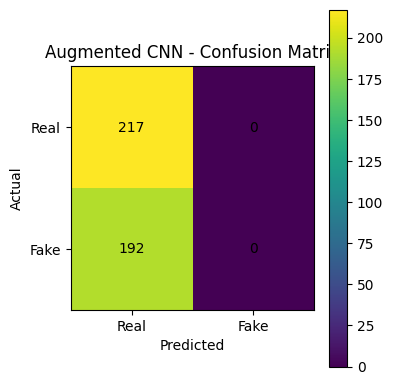

In [23]:
cm = confusion_matrix(y_val, y_pred_aug)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Augmented CNN - Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Real','Fake'])
plt.yticks([0,1], ['Real','Fake'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("plots/aug_cnn_confusion_matrix.png")
plt.show()

## 9) Augmentation + MobileNetV2

### i. Data Augmentation

In [24]:
train_datagen = ImageDataGenerator( 
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator()

### ii. Flow Data from Arrays

In [25]:
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=32
)

val_generator = val_datagen.flow(
    X_val, y_val,
    batch_size=32
)

### iii. Load Pretrained MobileNetV2 Base

In [29]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

### iv. Build the Full Model

In [30]:
aug_mobilenet = Sequential([
    base_model,
    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

aug_mobilenet.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 1,690,497 (6.45 MB)

 Non-trainable params: 731,584 (2.79 MB)

### v. Compile the Model

In [31]:
aug_mobilenet.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### vi. Train the model

In [32]:
history_aug_mn = aug_mobilenet.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2026-01-07 09:25:15.633476: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 09:25:15.830166: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


51/51 ━━━━━━━━━━━━━━━━━━━━ 42s 477ms/step - accuracy: 0.5117 - loss: 0.7980 - val_accuracy: 0.4866 - val_loss: 0.8026
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 295ms/step - accuracy: 0.6282 - loss: 0.6367 - val_accuracy: 0.5623 - val_loss: 0.7136
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 294ms/step - accuracy: 0.6654 - loss: 0.5939 - val_accuracy: 0.5330 - val_loss: 0.7742
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 288ms/step - accuracy: 0.7234 - loss: 0.5504 - val_accuracy: 0.5623 - val_loss: 0.8025
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 291ms/step - accuracy: 0.7395 - loss: 0.5189 - val_accuracy: 0.5672 - val_loss: 0.7684
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 291ms/step - accuracy: 0.7892 - loss: 0.4806 - val_accuracy: 0.5648 - val_loss: 0.8512
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 15s 301ms/step - accuracy: 0.8075 - loss: 0.4391 - val_accuracy: 0.5550 - val_loss: 0.8449
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 316ms/step - accuracy: 0.8201 - loss: 0.3939 - val_accuracy: 0.579

### vii. Evaluate the model


In [33]:
y_pred_aug_mn = (aug_mobilenet.predict(X_val) > 0.5).astype(int)

print(classification_report(y_val, y_pred_aug_mn))

13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 356ms/step
              precision    recall  f1-score   support

           0       0.72      0.41      0.52       217
           1       0.55      0.82      0.66       192

    accuracy                           0.60       409
   macro avg       0.64      0.61      0.59       409
weighted avg       0.64      0.60      0.59       409



### viii. Save the model

In [34]:
aug_mobilenet.save("trained_models/augmented_mobilenetv2_fake_face.h5")

### ix. Plot and Save Training Curves

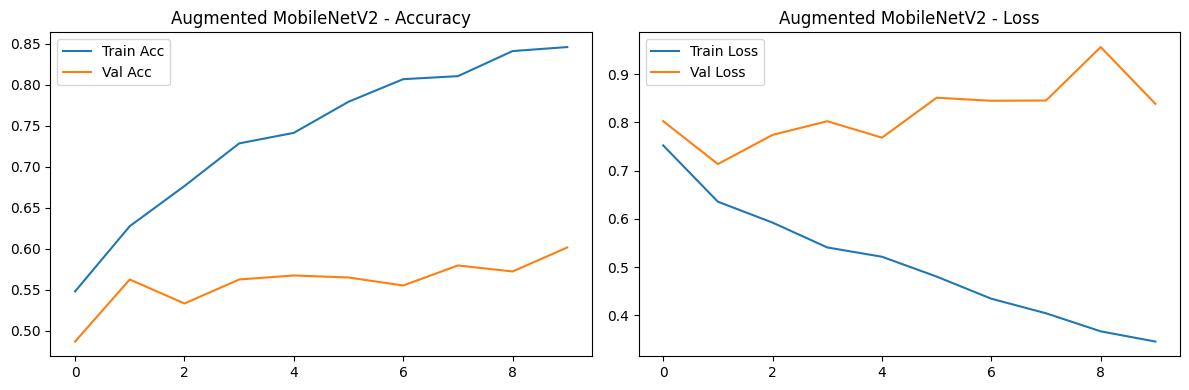

In [37]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_aug_mn.history['accuracy'], label='Train Acc')
plt.plot(history_aug_mn.history['val_accuracy'] , label='Val Acc')
plt.legend()
plt.title("Augmented MobileNetV2 - Accuracy")

plt.subplot(1,2,2)
plt.plot(history_aug_mn.history['loss'] , label='Train Loss')
plt.plot(history_aug_mn.history['val_loss'] , label='Val Loss')
plt.legend()
plt.title("Augmented MobileNetV2 - Loss")

plt.tight_layout()
plt.savefig("plots/aug_mobilenetv2_training_curves.png")
plt.show()


### x. Confusion Matrix

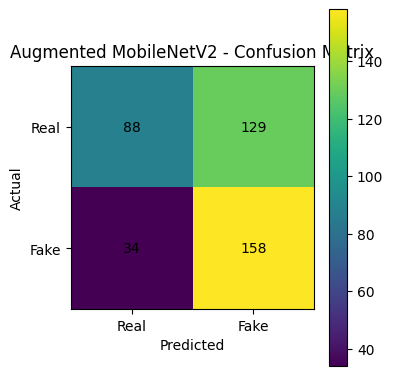

In [36]:
cm = confusion_matrix(y_val, y_pred_aug_mn)

plt.figure(figsize=(4,4))
plt.imshow(cm)
plt.title("Augmented MobileNetV2 - Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ['Real','Fake'])
plt.yticks([0,1], ['Real','Fake'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig("plots/aug_mobilenetv2_confusion_matrix.png")
plt.show()